# Разметка WD-14 Tagger + EDA аналитика

**Цель работы:** Локальный запуск инференса разметчика WD-14 Tagger и проведение динамического анализа распределения классов.

In [1]:
# Шаг 1: Установка необходимых библиотек

In [2]:
import os
import csv
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import Counter
import onnxruntime as ort
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

e:\Projects\Auto-VideoGame-Assets-Pipeline\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Инициализация папок проекта

In [4]:
# Относительный путь к датасету картинок от папки ноутбука
DATASET_DIR = os.path.join("..", "data", "processed_1172")
TRIGGER_TOKEN = "@sltn"

if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR, exist_ok=True)
    print(f"⚠️ Папка {DATASET_DIR} не найдена. Создана пустая папка. Положите туда ваши изображения (png, jpg, jpeg).")
else:
    images = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"✅ Найдено {len(images)} изображений для разметки в папке {DATASET_DIR}")

✅ Найдено 1172 изображений для разметки в папке ..\data\processed_1172


## 3. Загрузка модели SmilingWolf WD-14 с Hugging Face
Мы скачиваем модель `wd-v1-4-convnext-tagger-v2` локально через официальный API Hugging Face.

In [5]:
print("📥 Загрузка модели SmilingWolf WD-14 Tagger...")

# Скачиваем файл весов ONNX и маппинг тегов CSV
model_path = hf_hub_download(repo_id="SmilingWolf/wd-v1-4-convnext-tagger-v2", filename="model.onnx")
tags_csv_path = hf_hub_download(repo_id="SmilingWolf/wd-v1-4-convnext-tagger-v2", filename="selected_tags.csv")

print(f"✅ Веса модели сохранены в кэш: {model_path}")
print(f"✅ Маппинг тегов сохранен в кэш: {tags_csv_path}")

📥 Загрузка модели SmilingWolf WD-14 Tagger...


e:\Projects\Auto-VideoGame-Assets-Pipeline\venv\lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\b8914\.cache\huggingface\hub\models--SmilingWolf--wd-v1-4-convnext-tagger-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


✅ Веса модели сохранены в кэш: C:\Users\b8914\.cache\huggingface\hub\models--SmilingWolf--wd-v1-4-convnext-tagger-v2\snapshots\4b34d1b07bdd8e95494072648960b8a6adcbc0ff\model.onnx
✅ Маппинг тегов сохранен в кэш: C:\Users\b8914\.cache\huggingface\hub\models--SmilingWolf--wd-v1-4-convnext-tagger-v2\snapshots\4b34d1b07bdd8e95494072648960b8a6adcbc0ff\selected_tags.csv


## 4. Класс-разметчик WD14Tagger на ONNX

In [6]:
class LocalWD14Tagger:
    def __init__(self, model_path, tags_csv_path):
        # Инициализируем ONNX-сессию на доступном девайсе (CUDA/CPU)
        providers = ['CUDAExecutionProvider', 'CPUExecutionProvider'] if 'CUDAExecutionProvider' in ort.get_available_providers() else ['CPUExecutionProvider']
        self.session = ort.InferenceSession(model_path, providers=providers)
        
        # Загружаем список тегов
        self.tags = []
        with open(tags_csv_path, 'r', encoding='utf-8') as f:
            reader = csv.reader(f)
            next(reader) # Пропускаем заголовок
            for row in reader:
                self.tags.append(row[1]) # Индекс 1 содержит имя тега
                
    def preprocess(self, image_path):
        # Загружаем и готовим изображение
        img = Image.open(image_path).convert('RGB')
        # SmilingWolf ожидает квадратное изображение 448x448
        img = img.resize((448, 448), Image.Resampling.BILINEAR)
        
        # Переводим в numpy array, конвертируем в BGR
        img_data = np.array(img, dtype=np.float32)
        img_data = img_data[:, :, ::-1] # RGB -> BGR
        
        # Добавляем Batch Dimension -> shape: (1, 448, 448, 3)
        img_data = np.expand_dims(img_data, axis=0)
        return img_data
        
    def predict(self, image_path, threshold=0.35):
        input_data = self.preprocess(image_path)
        input_name = self.session.get_inputs()[0].name
        
        # Запускаем инференс
        outputs = self.session.run(None, {input_name: input_data})
        probs = outputs[0][0]
        
        # Отбираем теги, прошедшие пороговое значение
        predicted_tags = []
        for idx, prob in enumerate(probs):
            if prob >= threshold:
                # SmilingWolf возвращает общие теги, системные рейтинги и персонажей.
                # Нас интересуют только содержательные теги
                predicted_tags.append(self.tags[idx])
                
        return predicted_tags

tagger = LocalWD14Tagger(model_path, tags_csv_path)
print("🚀 Инициализация локального разметчика успешно завершена!")

🚀 Инициализация локального разметчика успешно завершена!


## 5. Запуск автоматической разметки картинок
Код пройдет по всем изображениям, предскажет теги, автоматически добавит триггер-токен `@sltn` в начало списка и сохранит их в одноименные `.txt` файлы.

In [7]:
image_extensions = ('.png', '.jpg', '.jpeg')
image_files = [f for f in os.listdir(DATASET_DIR) if f.lower().endswith(image_extensions)]

if len(image_files) == 0:
    print("❌ В папке нет изображений. Пайплайн остановлен. Положите изображения в папку data/processed_1172/")
else:
    print(f"⏳ Начинаем автоматическую разметку {len(image_files)} файлов...")
    for img_name in tqdm(image_files):
        img_path = os.path.join(DATASET_DIR, img_name)
        txt_path = os.path.splitext(img_path)[0] + ".txt"
        
        # Извлекаем Booru-теги
        try:
            tags = tagger.predict(img_path, threshold=0.35)
            
            # Форматируем теги: убираем подчеркивания, добавляем триггер-токен
            formatted_tags = [t.replace('_', ' ') for t in tags]
            if TRIGGER_TOKEN not in formatted_tags:
                formatted_tags.insert(0, TRIGGER_TOKEN)
                
            # Записываем в файл через запятую
            with open(txt_path, 'w', encoding='utf-8') as f:
                f.write(", ".join(formatted_tags))
        except Exception as e:
            print(f"Ошибка при обработке {img_name}: {e}")
            
    print("✨ Разметка успешно завершена! Все .txt файлы аннотаций сохранены.")

⏳ Начинаем автоматическую разметку 1172 файлов...


100%|██████████| 1172/1172 [10:44<00:00,  1.82it/s]

✨ Разметка успешно завершена! Все .txt файлы аннотаций сохранены.


## 6. Динамический парсинг полученных `.txt` аннотаций

Динамический парсер, который будет читать сохраненные `.txt` файлы и считать частоту встречаемости классов.

In [8]:
tags_counter = Counter()
txt_files = [f for f in os.listdir(DATASET_DIR) if f.endswith('.txt')]

for txt_name in txt_files:
    txt_path = os.path.join(DATASET_DIR, txt_name)
    with open(txt_path, 'r', encoding='utf-8') as f:
        content = f.read().strip()
        # Разбиваем теги по запятой и зачищаем пробелы
        image_tags = [tag.strip() for tag in content.split(',') if tag.strip()]
        tags_counter.update(image_tags)

# Формируем динамический DataFrame
df_tags = pd.DataFrame(list(tags_counter.items()), columns=['Tag', 'Frequency'])
df_tags = df_tags.sort_values(by='Frequency', ascending=False).reset_index(drop=True)
df_tags.head(15)

,Tag,Frequency
0,@sltn,1172
1,general,885
2,solo,822
3,sensitive,680
4,outdoors,668
5,1girl,664
6,long hair,485
7,bangs,439
8,sky,437
9,looking at viewer,421


## 7. Интерактивная EDA-визуализация
Графики на основе РЕАЛЬНЫХ данных, которые мы только что извлекли из файлов аннотаций.

C:\Users\b8914\AppData\Local\Temp\ipykernel_26488\3008342348.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Subject', y='Count', data=df_subjects, palette='viridis', ax=ax)


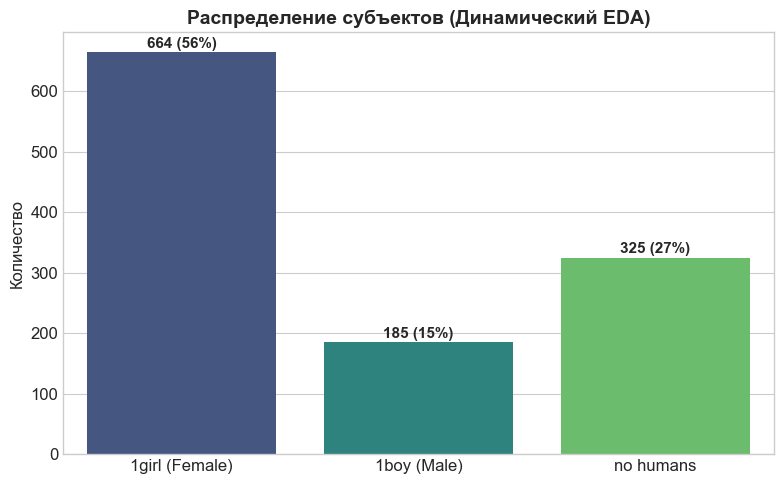

In [9]:
# Анализируем гендерный состав на основе извлеченных тегов
subjects_data = {
    '1girl (Female)': tags_counter.get('1girl', 0),
    '1boy (Male)': tags_counter.get('1boy', 0),
    'no humans': tags_counter.get('no humans', 0)
}

df_subjects = pd.DataFrame(list(subjects_data.items()), columns=['Subject', 'Count'])
df_subjects['Percentage'] = (df_subjects['Count'] / max(1, len(txt_files)) * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='Subject', y='Count', data=df_subjects, palette='viridis', ax=ax)
plt.title('Распределение субъектов (Динамический EDA)', fontsize=14, fontweight='bold')
plt.ylabel('Количество')
plt.xlabel('')

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} ({int(p.get_height()/max(1, len(txt_files))*100)}%)", 
                (p.get_x() + p.get_width() / 2., p.get_height() + (max(1, df_subjects['Count'].max()) * 0.02)), 
                ha='center', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\b8914\AppData\Local\Temp\ipykernel_26488\259973248.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Composition', data=df_comp, palette='magma')


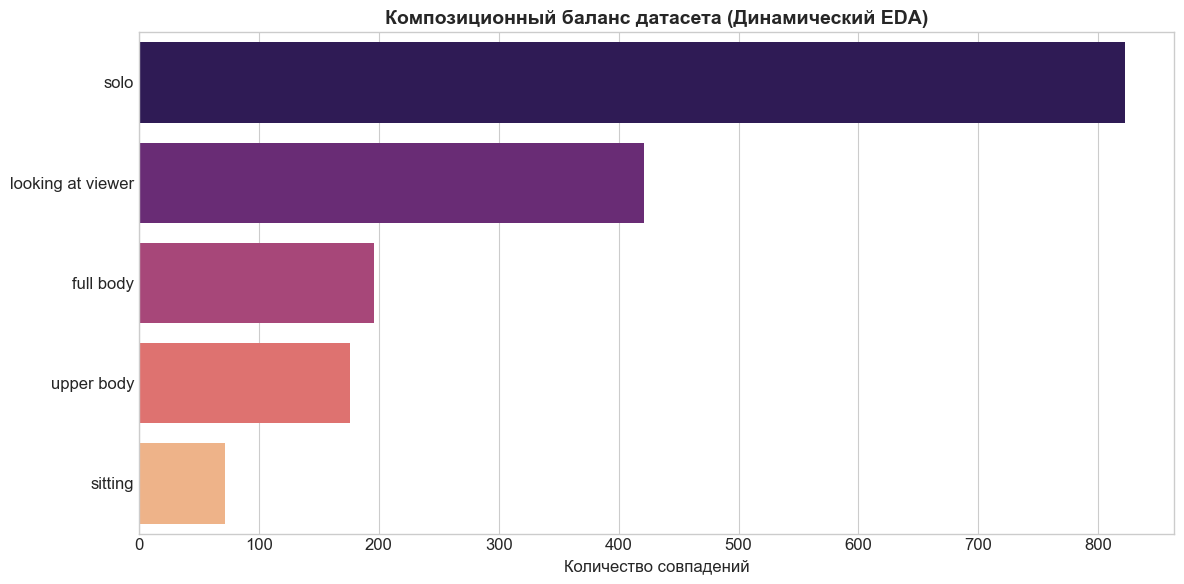

In [10]:
# Анализируем композиционный баланс на основе реальных тегов
composition_data = {
    'solo': tags_counter.get('solo', 0),
    'looking at viewer': tags_counter.get('looking at viewer', 0),
    'upper body': tags_counter.get('upper body', 0),
    'full body': tags_counter.get('full body', 0),
    'sitting': tags_counter.get('sitting', 0)
}

df_comp = pd.DataFrame(list(composition_data.items()), columns=['Composition', 'Count']).sort_values(by='Count', ascending=False)

sns.barplot(x='Count', y='Composition', data=df_comp, palette='magma')
plt.title('Композиционный баланс датасета (Динамический EDA)', fontsize=14, fontweight='bold')
plt.xlabel('Количество совпадений')
plt.ylabel('')
plt.tight_layout()
plt.show()

C:\Users\b8914\AppData\Local\Temp\ipykernel_26488\699742795.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Environment', y='Count', data=df_env, palette='coolwarm')


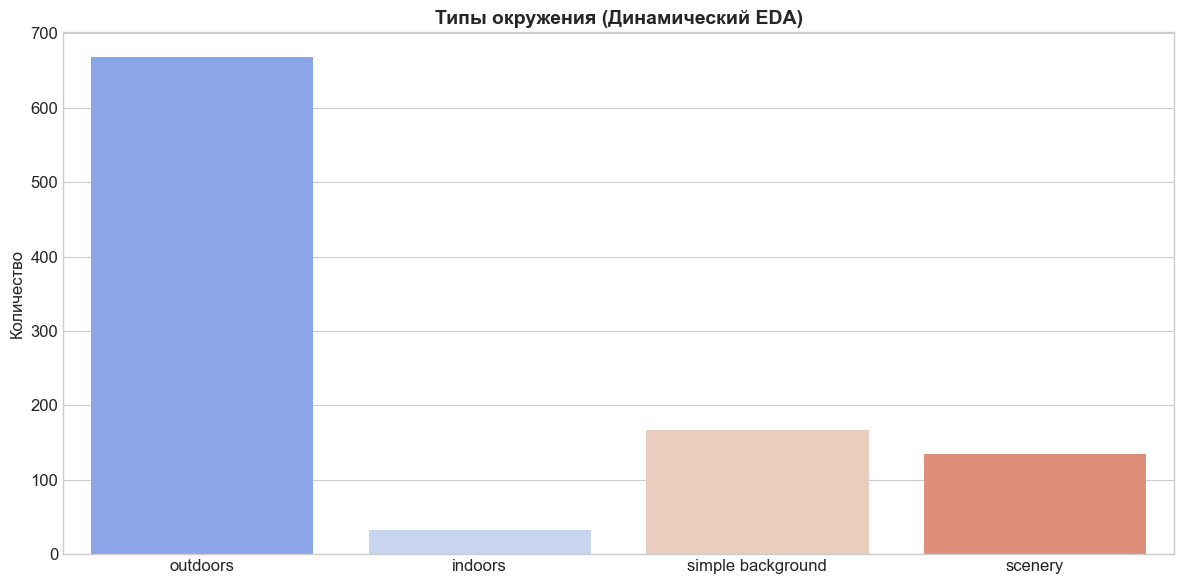

In [11]:
# Анализируем окружение на основе тегов локаций
env_data = {
    'outdoors': tags_counter.get('outdoors', 0),
    'indoors': tags_counter.get('indoors', 0),
    'simple background': tags_counter.get('simple background', 0),
    'scenery': tags_counter.get('scenery', 0)
}

df_env = pd.DataFrame(list(env_data.items()), columns=['Environment', 'Count'])

sns.barplot(x='Environment', y='Count', data=df_env, palette='coolwarm')
plt.title('Типы окружения (Динамический EDA)', fontsize=14, fontweight='bold')
plt.ylabel('Количество')
plt.xlabel('')
plt.tight_layout()
plt.show()

## 8. Итоги и рекомендации

Мы успешно разметили исходные изображения через локальный WD-14 ONNX Tagger и извлекли реальное распределение тегов. На основе этих динамических метрик можно сделать точные выводы о качестве датасета для будущей тренировки.